In [1]:
from Utils.dataset_utils import DatasetUtils
import pandas as pd
from collections import Counter

In [2]:
train_dataset, _ = DatasetUtils.download_celeba(
    train_csv="original_merged",
    base_path="../../../data/celeba",
    debug=True,
)

In [3]:
train_dataset.indexes

range(0, 202599)

In [4]:
df = pd.read_csv("../../../data/celeba/original_merged.csv")

In [5]:
targets = [1 if item == 1 else 0 for item in df["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df["Male"]]

In [6]:
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,split,Target
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,-1,1,-1,-1,1,0.137514,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,-1,-1,-1,1,-0.432273,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,1,1.841473,0
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,-1,1,1,-1,1,-0.080797,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,1,-1,-1,1,1.045482,1


In [7]:
df.keys()

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'split', 'Target'],
      dtype='object')

In [8]:
df["Oval_Face"].value_counts()

-1    145032
 1     57567
Name: Oval_Face, dtype: int64

In [9]:
df_attractive = df[df["Oval_Face"] == 1]
df_not_attractive = df[df["Oval_Face"] == -1]

In [10]:
df_attractive.shape

(57567, 43)

In [11]:
df_not_attractive.shape

(145032, 43)

In [12]:
targets = [1 if item == 1 else 0 for item in df_attractive["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df_attractive["Male"]]

sensitive_target = [(s, t) for t, s in zip(targets, sensitive_values)]
Counter(sensitive_target)

Counter({(0, 1): 27103, (1, 1): 10046, (0, 0): 11894, (1, 0): 8524})

In [13]:
# drop 50% of the samples where the target is 1 and the sensitive value is 1
# dropped_indexes_1 = (
#     df_attractive[(df_attractive["Smiling"] == 1) & (df_attractive["Male"] == -1)]
#     .sample(frac=0.4)
#     .index
# )

# dropped_indexes_2 = (
#     df_attractive[(df_attractive["Smiling"] == -1) & (df_attractive["Male"] == -1)]
#     .sample(frac=0.7)
#     .index
# )

# df_dropped_1 = df_attractive.loc[dropped_indexes_1]
# df_dropped_2 = df_attractive.loc[dropped_indexes_2]

# df_attractive = df_attractive.drop(dropped_indexes_1)
# df_attractive = df_attractive.drop(dropped_indexes_2)


df_attractive.shape

(57567, 43)

In [14]:
# df_not_attractive = pd.concat([df_not_attractive, df_dropped_1])
# df_not_attractive = pd.concat([df_not_attractive, df_dropped_2])
df_not_attractive.shape

(145032, 43)

In [15]:
targets = [1 if item == 1 else 0 for item in df_not_attractive["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df_not_attractive["Male"]]

sensitive_target = [(s, t) for t, s in zip(targets, sensitive_values)]
Counter(sensitive_target)

Counter({(0, 1): 36768, (1, 0): 42112, (0, 0): 42400, (1, 1): 23752})

In [16]:
# # drop 50% of the samples where the target is 1 and the sensitive value is 1
# dropped_indexes_1 = (
#     df_not_attractive[
#         (df_not_attractive["Smiling"] == 1) & (df_not_attractive["Male"] == -1)
#     ]
#     .sample(frac=0.2)
#     .index
# )


# df_dropped_1 = df_not_attractive.loc[dropped_indexes_1]

# df_not_attractive = df_not_attractive.drop(dropped_indexes_1)


# df_not_attractive.shape

In [17]:
df_attractive.to_csv("../../../data/celeba/df_attractive_211.csv")
df_not_attractive.to_csv("../../../data/celeba/df_not_attractive_211.csv")

In [18]:
# df_attractive = pd.read_csv("../../../data/celeba/df_attractive_111.csv")
# df_not_attractive = pd.read_csv("../../../data/celeba/df_not_attractive_111.csv")

# Test New Distribution

In [19]:
train_dataset_attractive, _ = DatasetUtils.download_celeba(
    train_csv="df_attractive_211",
    base_path="../../../data/celeba",
    debug=True,
)

In [20]:
len(train_dataset_attractive.targets)

57567

In [21]:
from Utils.utils import Utils
from Utils.train_parameters import TrainParameters

/home/lcorbucci/Unfairness-Regularization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-11-03 07:46:25,902	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/home/lcorbucci/Unfairness-Regularization/.venv/lib/python3.10/site-packages/wandb/analytics/sentry.py:82: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  self.hub = sentry_sdk.Hub(client)


In [22]:
train_parameters = TrainParameters(
    epochs=10,
    device="cuda",
    batch_size=64,
    seed=1,
    metric="disparity",
    optimizer="adam",
)

In [23]:
train_path_attractive = Utils.prepare_dataset_for_FL(
    dataset=train_dataset_attractive,
    dataset_name="celeba",
    base_path="../../../data/",
)

Generating unified dataset
Data Correctly downloaded


Partitioning the dataset
Counter({1: 37149, 0: 20418})
SPLITTING THE DATASET USING the representative partitioning
Mean of disparity 0.15348935800073188 - std 0.049840972507570906
Mean of disparity 0.15348935800073188 - std 0.04984097250757091
[202, 186, 169, 174, 179, 185, 182, 182, 182, 169, 170, 178, 204, 188, 163, 185, 177, 176, 172, 181, 182, 176, 172, 193, 170, 168, 184, 180, 177, 186, 161, 181, 179, 210, 196, 173, 198, 170, 184, 185, 174, 178, 191, 186, 178, 169, 183, 177, 185, 183, 185, 170, 166, 193, 172, 181, 185, 179, 180, 192, 190, 166, 177, 181, 172, 181, 177, 190, 187, 209, 189, 169, 182, 162, 178, 188, 173, 186, 182, 157, 174, 178, 195, 181, 165, 180, 177, 178, 168, 167, 181, 191, 170, 195, 173, 174, 200, 178, 170, 193, 193, 178, 185, 153, 170, 186, 174, 187, 165, 174, 190, 178, 196, 188, 197, 180, 173, 188, 169, 178, 174, 177, 179, 158, 175, 175, 194, 178, 192, 189, 188, 189, 182, 174, 171, 178, 182, 187, 182, 191, 178, 164, 186, 177, 174, 182, 193, 191, 178, 182]
[73, 

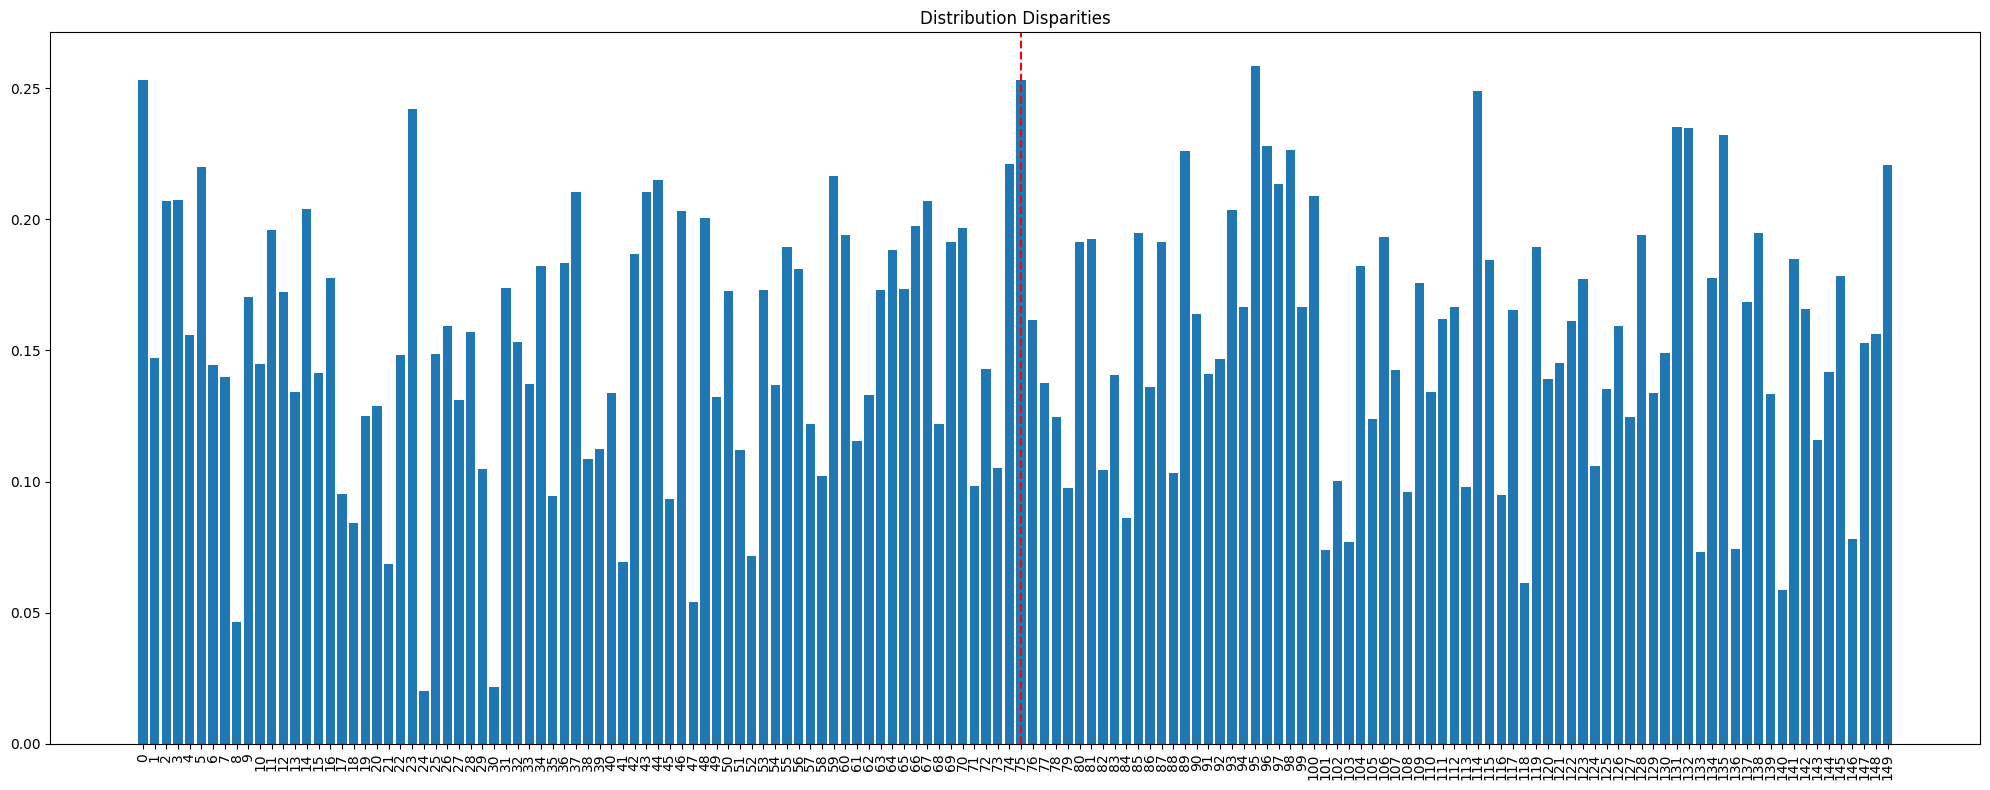

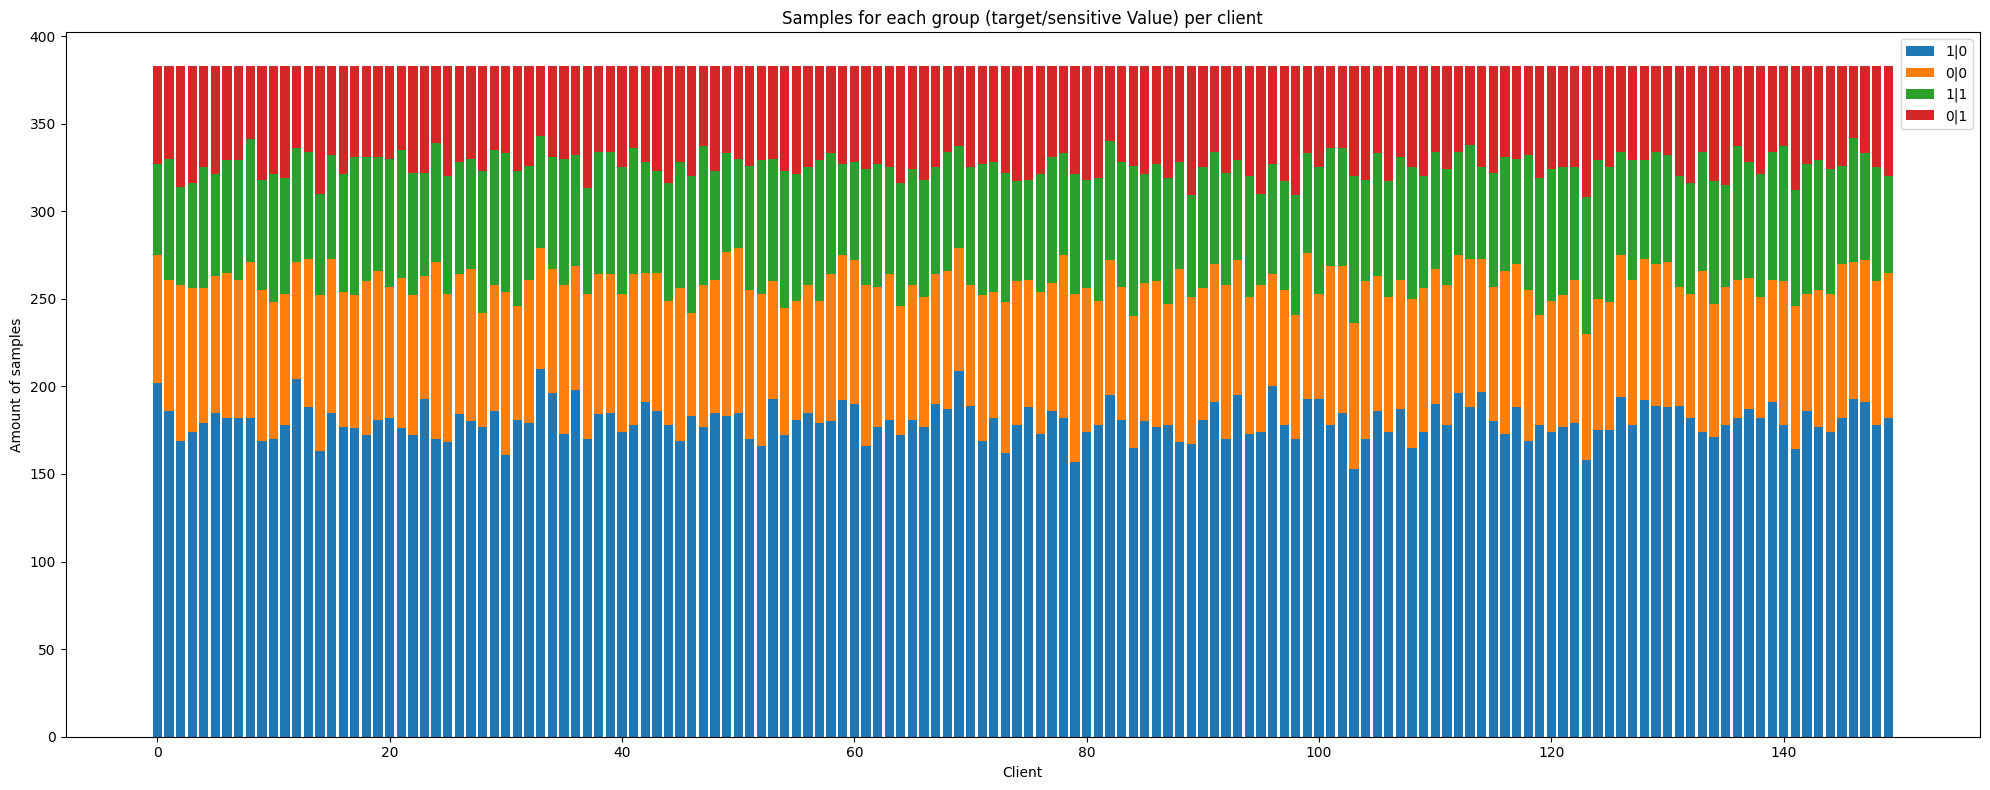

In [25]:
# Attractive Partitioning

# 103833/150
fed_dir = Utils.do_fl_partitioning(
    train_path_attractive,
    pool_size=150,
    num_classes=2,
    val_ratio=0,
    partition_type="representative",
    train_parameters=train_parameters,
    group_to_reduce=(1, 1),
    group_to_increment=(0, 1),
    number_of_samples_per_node=383,
    ratio_unfair_nodes=0.5,
    ratio_unfairness=(0, 0),
    splitted_data_dir="federated",
)

In [26]:
train_dataset_NOT_attractive, _ = DatasetUtils.download_celeba(
    train_csv="df_not_attractive_211",
    base_path="../../../data/celeba",
    debug=True,
)

len(train_dataset_NOT_attractive.targets)

145032

In [27]:
train_path_NOT_attractive = Utils.prepare_dataset_for_FL(
    dataset=train_dataset_NOT_attractive,
    dataset_name="celeba",
    base_path="../../../data/",
)

Generating unified dataset
Data Correctly downloaded


Partitioning the dataset
Counter({0: 84512, 1: 60520})
SPLITTING THE DATASET USING the representative partitioning
Mean of disparity 0.10377435932136994 - std 0.030915070172384713
Mean of disparity 0.10377435932136997 - std 0.030915070172384713
[248, 255, 236, 248, 255, 233, 240, 256, 241, 217, 222, 243, 225, 254, 226, 268, 235, 260, 228, 238, 264, 225, 247, 256, 248, 254, 241, 246, 232, 230, 250, 243, 234, 246, 249, 251, 239, 229, 260, 226, 254, 241, 242, 259, 247, 229, 229, 247, 231, 229, 243, 245, 236, 262, 239, 231, 245, 247, 258, 235, 213, 267, 250, 260, 246, 239, 254, 257, 282, 236, 213, 240, 267, 239, 260, 257, 257, 221, 224, 230, 234, 248, 253, 266, 281, 231, 225, 245, 258, 276, 239, 226, 242, 246, 232, 259, 227, 238, 269, 242, 231, 245, 239, 246, 231, 249, 260, 238, 260, 240, 258, 239, 232, 244, 249, 261, 258, 284, 274, 248, 233, 250, 233, 229, 270, 236, 249, 248, 249, 221, 221, 254, 237, 231, 247, 236, 236, 251, 280, 248, 235, 245, 227, 245, 259, 273, 254, 249, 243, 263]
[263

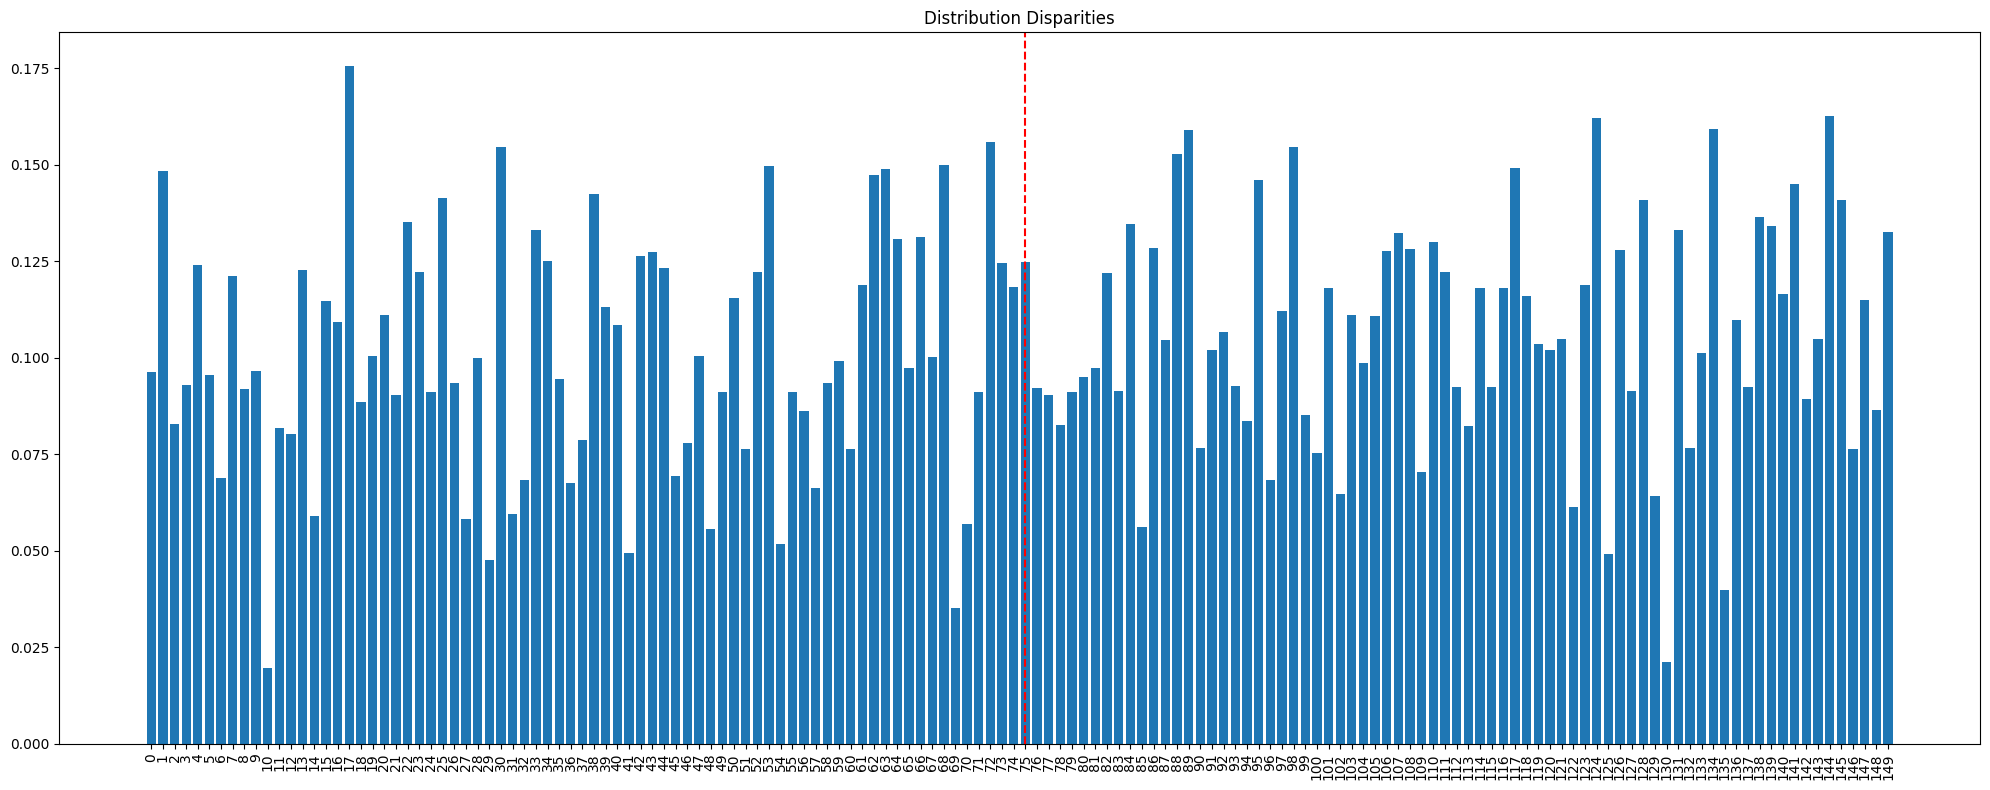

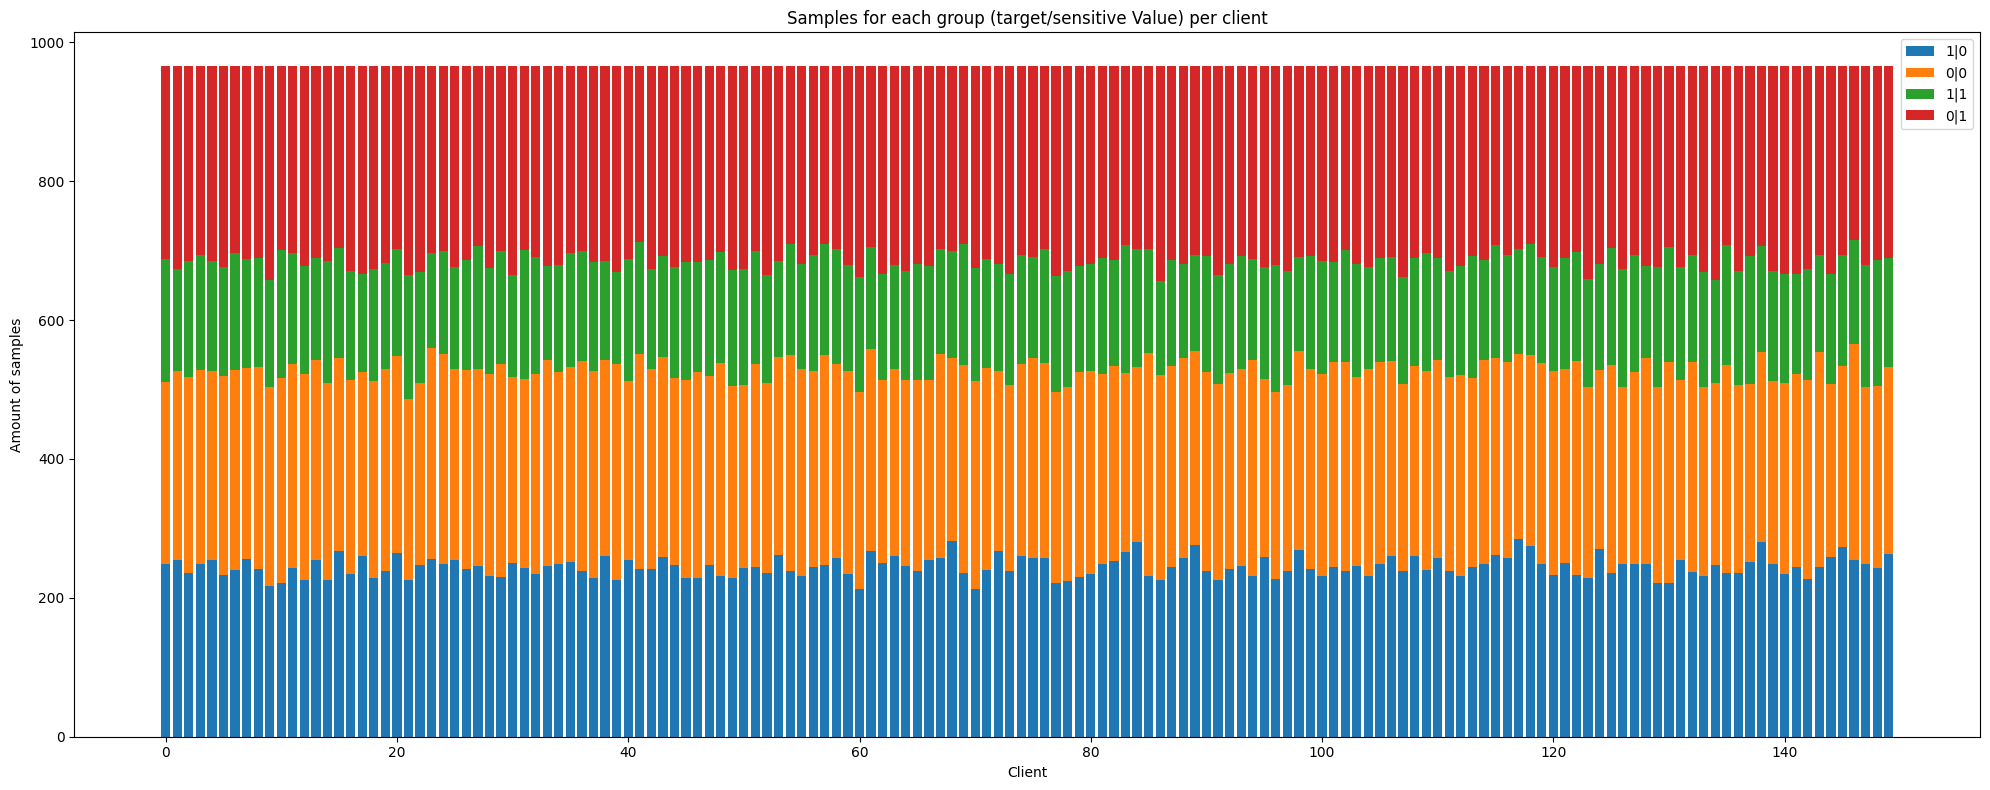

In [28]:
# Attractive Partitioning
fed_dir = Utils.do_fl_partitioning(
    train_path_NOT_attractive,
    pool_size=150,
    num_classes=2,
    val_ratio=0,
    partition_type="representative",
    train_parameters=train_parameters,
    group_to_reduce=(1, 1),
    group_to_increment=(0, 1),
    number_of_samples_per_node=966,
    ratio_unfair_nodes=0.5,
    ratio_unfairness=(0, 0),
    splitted_data_dir="federated",
)